In [11]:
from rpgpy import rpg2nc
import numpy as np
from gfatpy.radar.rpg_nc import rpg
import os
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib as mpl
from gfatpy.radar.retrieve import retrieve
from IPython import get_ipython
from rpgpy import read_rpg
import xarray as xr
import pandas as pd
import glob
%matplotlib inline
# plt.close('all')
# ipython = get_ipython()
# if ipython is not None:
#     ipython.run_line_magic('matplotlib', 'inline')

In [45]:
radar_str = "nebula_ka"
date_str = "2024/07/28"

raw_folder = f"/Volumes/RAW-1/UGR/{radar_str}/"
# product_folder = f"/Volumes/PRODUCTS-1/UGR/{radar_str}/{date_str}/"
product_folder = f"/Users/matheussilva/Documents/granada_data/{radar_str}/{date_str}/"
figure_folder = Path(f"/Users/matheussilva/Documents/granada_data/figures/")

In [47]:
pattern = "*_16*_ZEN.LV0"

# check if exist the folder raw folder first
if os.path.exists(raw_folder):
    raw_files = os.path.join(raw_folder, date_str) # folder with raw files
    print("path to raw files: ", raw_files)

    print("path to products files:", product_folder)

    print("make product folder if it does not exist ...")
    # make the folder and subfolders if they do not exist
    os.makedirs(product_folder, exist_ok=True)

    # get the list of raw files lv1
    filepaths = glob.glob(os.path.join(raw_files, pattern))
    
    print("converting files to netcdf if they do not exist ...")
    # check if there are files to process or if they already exist
    if len(filepaths) == 0 or all([os.path.exists(os.path.join(product_folder, f.split("/")[-1]+".nc")) for f in filepaths]):
        print("There are no files to process or they already exist")
    else:
        # converting to raw files to netcdf using rpgpy
        for f in filepaths:
            print("converting file:", f)
            rpg2nc(f, os.path.join(product_folder, f.split("/")[-1]+".nc"))

else:
    print("The raw folder does not exist")

# get filepath of files ended with RHI.LV1.nc
filepaths = glob.glob(os.path.join(product_folder, pattern+".nc"))

# order the files by date
filepaths = sorted(filepaths)

# # check if there are files to process
# if len(filepaths) == 0:
#     print("There are no files to process")
# else:
#     print("netcdf files created by rpgpy:")
#     for f in filepaths:
#         print(f)

#     # check if filepaths is a list:
#     print("\nreading the file as radar class in gfatpy...")
#     if isinstance(filepaths, list):
#         radar = rpg(filepaths[0])
#     else:
#         radar = rpg(filepaths)

path to raw files:  /Volumes/RAW-1/UGR/nebula_ka/2024/07/28
path to products files: /Users/matheussilva/Documents/granada_data/nebula_ka/2024/07/28/
make product folder if it does not exist ...
converting files to netcdf if they do not exist ...
converting file: /Volumes/RAW-1/UGR/nebula_ka/2024/07/28/240728_160001_P00_ZEN.LV0
converting file: /Volumes/RAW-1/UGR/nebula_ka/2024/07/28/240728_162349_P00_ZEN.LV0
converting file: /Volumes/RAW-1/UGR/nebula_ka/2024/07/28/240728_164238_P00_ZEN.LV0


RPGFileError: Timestamp 0 is outside the expected range [743877758, 743878588].

<class 'numpy.ndarray'>


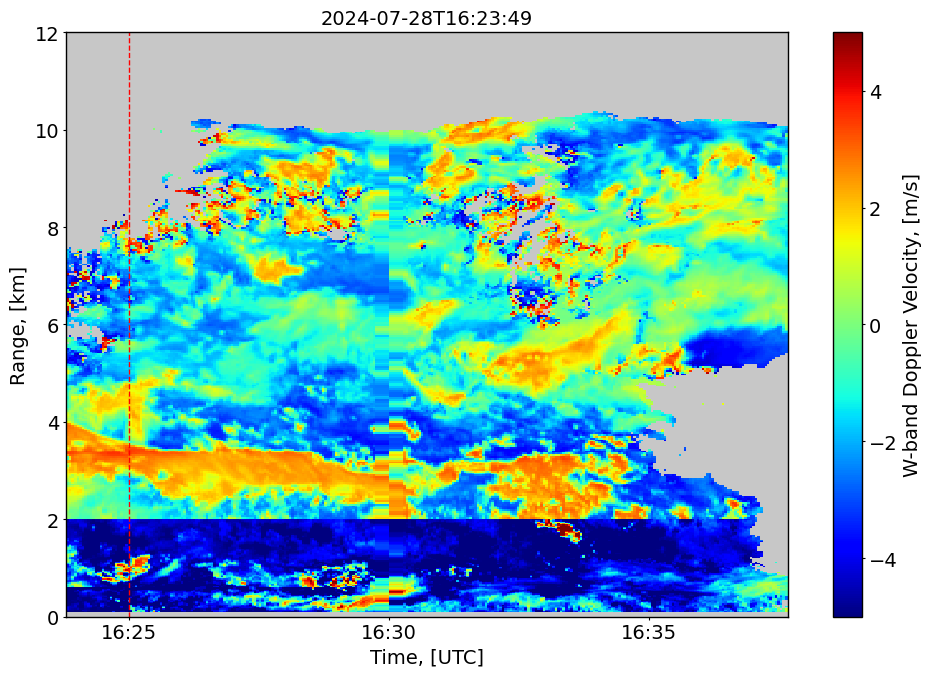

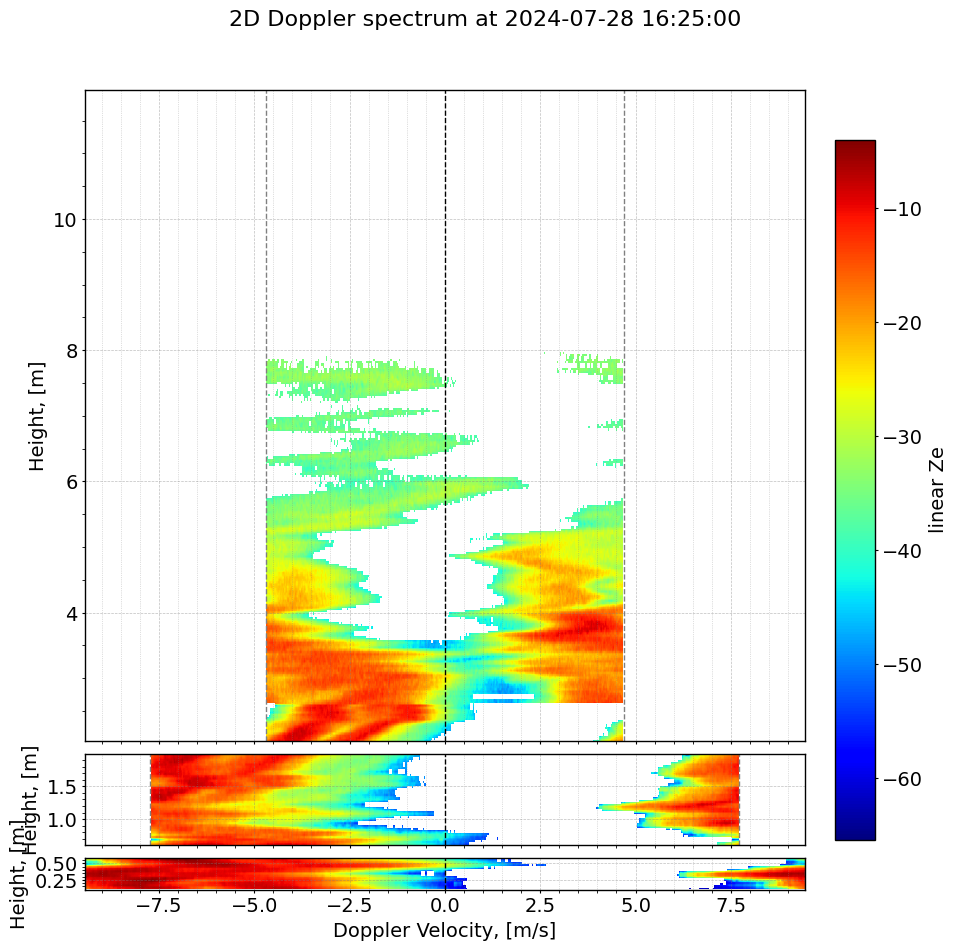

In [44]:
lv0_filepaths = sorted( glob.glob(os.path.join(product_folder, "*ZEN.LV0.nc")) )

i=1
lv0_file = lv0_filepaths[i]

radar_lv0 = rpg(lv0_file)
lv1_file = lv0_file.replace("ZEN.LV0.nc", "ZEN.LV1.nc")
radar_lv1 = rpg(lv1_file)

zlimits = np.array([0, 12000])

# plot data plot zen for lv1
figs, fig_filepath = radar_lv1.plot_zen(
    variable=[
        # "dBZe",
        "v",
        # "width",
        # "skewness",
        # "kurtosis",
    ],
    range_limits=zlimits/1000,
    dpi=400,
    savefig=False,
    output_dir=figure_folder,
    **{"cmap":"jet"},
)

date_str = pd.to_datetime(str(radar_lv0.data.time[0].values)).strftime('%Y-%m-%d')
target_time = np.datetime64(date_str + 'T16:25')
# Use xarray's built-in method to find the index of the closest time
closest_time_index = radar_lv0.data.time.sel(time=target_time, method='nearest').time
# add a verical line to the zen plot at the target time
# figs[1].axes[0].axvline(closest_time_index.values, color="red", linestyle="--")
figs[0].axes[0].axvline(closest_time_index.values, color="red", linestyle="--")
# savefig to the same folder
# figs[0].savefig(fig_filepath[0])

if radar_lv0.level == 0:
    fig, filepath = radar_lv0.plot_2D_spectrum(
        variable="v",
        target_time= closest_time_index.time.values,
        range_limits=zlimits,
        vmin=-60,
        vmax=0,
        **{"savefig": True, "output_dir": figure_folder}
    )

# if radar_lv0.level == 0:
#     fig, filepath = radar_lv0.plot_spectra_by_range(
#         target_time= closest_time_index.time.values,
#         range_slice=(1500, 2500),
#         **{"savefig": False}
#     )